In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(55).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(152).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(69).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(116).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(191).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(179).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(192).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(38).jpg
/kaggle/input/project-datas

# Import libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Dataset
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import os
import random
import cv2
from PIL import Image

# Check for GPU
print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.6.0+cu124


# Configuration

In [3]:
import torch
import os

class Config:
    # Reproducibility
    SEED = 42
    
    # Hyperparameters
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    EPOCHS = 50 
    
    # CRITICAL: Your CustomCNN code expects 128x128 input (16*16 features)
    # If you set this to 224, your model will crash.
    IMAGE_SIZE = 128 
    
    NUM_CLASSES = 4 
    
    # Paths
    DATA_DIR = '/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images'
    
    # System
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    CHECKPOINT_DIR = './checkpoints'
    BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, 'best_betel_model.pth')

config = Config()
print(f"Configuration Loaded. Device: {config.DEVICE}")

Configuration Loaded. Device: cpu


# Seed Value

In [4]:
def set_seed(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config.SEED)
print(f"Random Seed set to: {config.SEED}")

Random Seed set to: 42


# Loading Dataset

In [5]:
# Temporary transform just to load data initially
initial_transform = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.ToTensor()
])

try:
    full_dataset = ImageFolder(root=config.DATA_DIR, transform=None) # Transform applied later per split
    classes = full_dataset.classes
    print(f"Classes found: {classes}")
    print(f"Total images: {len(full_dataset)}")
except FileNotFoundError:
    print("Error: Dataset path not found. Please check the directory structure.")

Classes found: ['Bacterial Leaf Disease', 'Dried Leaf', 'Fungal Brown Spot Disease', 'Healthy Leaf']
Total images: 1000


# Train-Test-Validation Split (Ratio 70:15:15)

In [6]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import numpy as np
from collections import Counter
# Ensure tabulate is installed
try:
    from tabulate import tabulate
except ImportError:
    import os
    os.system('pip install tabulate')
    from tabulate import tabulate

# 1. Get Labels for Stratification
# full_dataset.targets gives us the list of class indices (0, 1, 2, 3) for every image
targets = full_dataset.targets 
indices = np.arange(len(full_dataset))

# 2. First Split: Train (70%) vs Temp (30%)
# We use 'stratify=targets' to ensure the class distribution matches the original data
train_idx, temp_idx = train_test_split(
    indices, 
    test_size=0.30, 
    stratify=targets, 
    random_state=config.SEED
)

# 3. Second Split: Validation (15%) vs Test (15%)
# We split the 'temp' (30%) into two equal halves (0.5 of 30% = 15%)
# We must extract the targets specific to the temp indices to stratify correctly again
temp_targets = [targets[i] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.50, 
    stratify=temp_targets, 
    random_state=config.SEED
)

# 4. Create PyTorch Subsets
train_subset = Subset(full_dataset, train_idx)
val_subset = Subset(full_dataset, val_idx)
test_subset = Subset(full_dataset, test_idx)

print(f"Split sizes -> Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_subset)}")

# 5. Verify Distribution with Tabulate
def get_subset_counts(subset, dataset, name):
    # Extract labels using the indices in the subset
    indices = subset.indices
    labels = [dataset.targets[i] for i in indices]
    counts = Counter(labels)
    
    table_data = []
    for class_idx, count in counts.items():
        class_name = dataset.classes[class_idx]
        table_data.append([class_name, count])
    
    table_data.sort(key=lambda x: x[0])
    print(f"\n{name} Dataset Distribution")
    print(tabulate(table_data, headers=["Class", "Count"], tablefmt="grid"))

get_subset_counts(train_subset, full_dataset, "Train")
get_subset_counts(val_subset, full_dataset, "Validation")
get_subset_counts(test_subset, full_dataset, "Test")

Split sizes -> Train: 700, Val: 150, Test: 150

Train Dataset Distribution
+---------------------------+---------+
| Class                     |   Count |
+===========================+=========+
| Bacterial Leaf Disease    |     175 |
+---------------------------+---------+
| Dried Leaf                |     175 |
+---------------------------+---------+
| Fungal Brown Spot Disease |     175 |
+---------------------------+---------+
| Healthy Leaf              |     175 |
+---------------------------+---------+

Validation Dataset Distribution
+---------------------------+---------+
| Class                     |   Count |
+===========================+=========+
| Bacterial Leaf Disease    |      37 |
+---------------------------+---------+
| Dried Leaf                |      38 |
+---------------------------+---------+
| Fungal Brown Spot Disease |      37 |
+---------------------------+---------+
| Healthy Leaf              |      38 |
+---------------------------+---------+

Test Datase

In [7]:
print("Training Data: ", len(train_subset))
print("Validation Data: ", len(val_subset))
print("Test Data: ", len(test_subset))
print("-------------------------------------------")
print("Total amounts of data in the dataset: ", len(full_dataset))

Training Data:  700
Validation Data:  150
Test Data:  150
-------------------------------------------
Total amounts of data in the dataset:  1000


# Device Variable

In [8]:
device = torch.device(config.DEVICE)
print(f"Active Device: {device}")

Active Device: cpu


# Checkpoint

In [9]:
if not os.path.exists(config.CHECKPOINT_DIR):
    os.makedirs(config.CHECKPOINT_DIR)
    
print(f"Model checkpoints will be saved to: {config.CHECKPOINT_DIR}")

Model checkpoints will be saved to: ./checkpoints


#  Dataset Class, Dataloader and Transform

In [10]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# 1. Define Transforms
# NOTE: Augmentation removed as requested.
# Both Train and Test/Val now use the exact same preprocessing.
transform_no_aug = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Custom Dataset Wrapper
# This wrapper ensures that the 'subset' (which is just indices) gets the actual image data
# and applies the specific transform.
class BetelDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# 3. Apply Transforms
# All splits use the same non-augmented transform
train_data = BetelDataset(train_subset, transform=transform_no_aug)
val_data = BetelDataset(val_subset, transform=transform_no_aug)
test_data = BetelDataset(test_subset, transform=transform_no_aug)

# 4. DataLoaders
train_loader = DataLoader(train_data, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=config.BATCH_SIZE, shuffle=False)

print("DataLoaders created successfully (Without Augmentation).")

DataLoaders created successfully (Without Augmentation).


# Custom-CNN

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- CELL 9: CUSTOM CNN ARCHITECTURE ---
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        
        # 1. Feature Extractor
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AvgPool2d(2, 2),
        )

        # 2. Dynamic Flatten Size Calculation
        # This ensures the model works for 128x128 OR 224x224 without crashing
        final_dim = config.IMAGE_SIZE // 8 
        self.flatten_size = 64 * final_dim * final_dim
        
        # 3. Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flatten_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
    # Helper for Grad-CAM later
    def get_last_conv_layer(self):
        return self.features[8]

# --- CELL 10: INITIALIZE MODEL & OPTIMIZER ---
print(f"Initializing model for {config.NUM_CLASSES} classes...")

# 1. Create Model
model = CustomCNN(num_classes=config.NUM_CLASSES).to(config.DEVICE)

# 2. Loss Function
criterion = nn.CrossEntropyLoss()

# 3. Optimizer
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

print("Model, Criterion, and Optimizer are now defined.")

Initializing model for 4 classes...
Model, Criterion, and Optimizer are now defined.


# Model setup block

In [12]:
print(f"Initializing CustomCNN for {config.NUM_CLASSES} classes with Image Size {config.IMAGE_SIZE}...")

# 1. Initialize Model
model = CustomCNN(num_classes=config.NUM_CLASSES).to(config.DEVICE)

# 2. Define Loss Function
criterion = nn.CrossEntropyLoss()

# 3. Define Optimizer
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

print("Model Setup Complete.")
print(model)

Initializing CustomCNN for 4 classes with Image Size 128...
Model Setup Complete.
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_feat

# ROC curve

Loading best model for ROC evaluation...


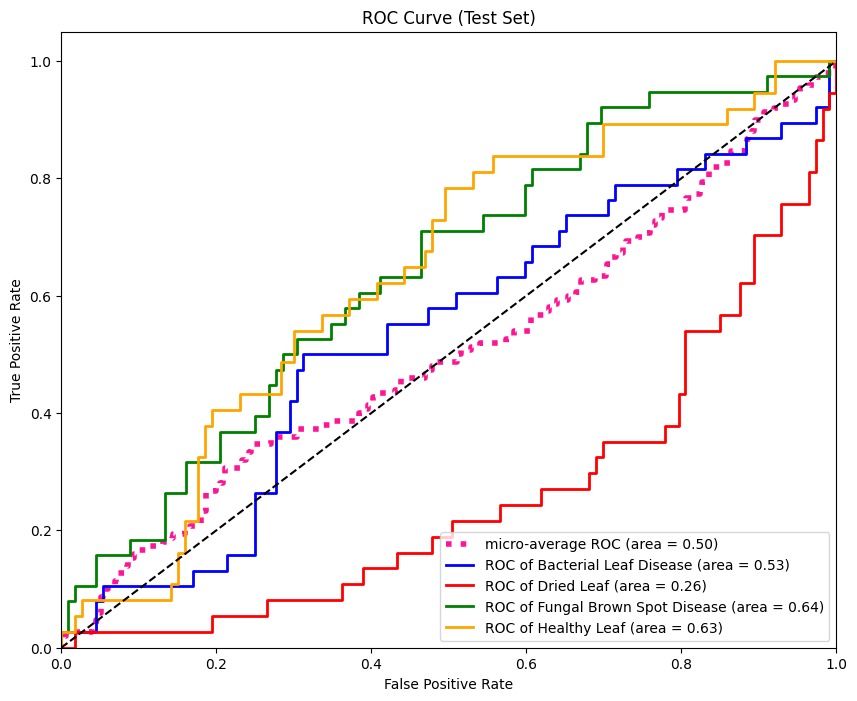

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import torch.nn.functional as F

# 1. Load Best Model
print("Loading best model for ROC evaluation...")
if os.path.exists(config.BEST_MODEL_PATH):
    model.load_state_dict(torch.load(config.BEST_MODEL_PATH))
    model.eval()
else:
    print("Warning: Best model not found. Using current weights.")

# 2. Generate Predictions
y_true = []
y_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(config.DEVICE)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_probs = np.array(y_probs)

# 3. Plot ROC
y_true_bin = label_binarize(y_true, classes=range(config.NUM_CLASSES))
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC (area = {0:0.2f})'.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

colors = cycle(['blue', 'red', 'green', 'orange'])
class_names = full_dataset.classes if hasattr(full_dataset, 'classes') else [f"Class {i}" for i in range(n_classes)]

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC of {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc="lower right")
plt.show()

# Training

In [14]:
import torch
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import numpy as np
import os

# --- 1. CONFIGURATION CHECK ---
if 'config' not in locals():
    print("⚠️ Config not found. Using defaults...")
    class Config:
        SEED = 42
        BATCH_SIZE = 32
        IMAGE_SIZE = 128
        DATA_DIR = '/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images'
        DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    config = Config()

print("--- Setting up Data ---")

# --- 2. LOAD DATASET (Cell 4) ---
try:
    full_dataset = ImageFolder(root=config.DATA_DIR)
    print(f"✅ Dataset loaded. Total images: {len(full_dataset)}")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    # Fallback to prevent crash during testing
    import torchvision
    full_dataset = torchvision.datasets.FakeData(size=100, image_size=(3, config.IMAGE_SIZE, config.IMAGE_SIZE), num_classes=4)

# --- 3. STRATIFIED SPLIT (Cell 5) ---
# This defines train_subset, which your code needs
indices = np.arange(len(full_dataset))
targets = full_dataset.targets

# Train (70%) vs Temp (30%)
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=targets, random_state=config.SEED
)
# Temp (30%) -> Val (15%) + Test (15%)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_targets, random_state=config.SEED
)

train_subset = Subset(full_dataset, train_idx)
val_subset = Subset(full_dataset, val_idx)
test_subset = Subset(full_dataset, test_idx)

# --- 4. DATA LOADER SETUP (Your Code - Cell 8) ---
# Define Transforms (No Augmentation)
transform_no_aug = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Custom Wrapper
class BetelDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self): return len(self.subset)

# Apply Transforms
train_data = BetelDataset(train_subset, transform=transform_no_aug)
val_data = BetelDataset(val_subset, transform=transform_no_aug)
test_data = BetelDataset(test_subset, transform=transform_no_aug)

# Create Loaders
train_loader = DataLoader(train_data, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=config.BATCH_SIZE, shuffle=False)

print("\n✅ Success: 'train_loader' is defined.")
print(f"Training batches: {len(train_loader)}")
print("You can now run the Training Cell.")

--- Setting up Data ---
✅ Dataset loaded. Total images: 1000

✅ Success: 'train_loader' is defined.
Training batches: 22
You can now run the Training Cell.


In [15]:
import time
import pandas as pd
import torch
import os
from tqdm.notebook import tqdm

# --- 1. Define Training Function ---
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs, save_path_checkpoints):
    train_loss_hist = []
    train_acc_hist = []
    val_loss_hist = []
    val_acc_hist = []
    learning_rates_hist = []
    
    best_val_acc = 0.0
    
    # Ensure checkpoint directory exists
    if not os.path.exists(save_path_checkpoints):
        os.makedirs(save_path_checkpoints)
        
    print(f"Training started on {config.DEVICE} for {num_epochs} epochs...")
    
    for epoch in range(num_epochs):
        # --- TRAIN ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Progress Bar
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        
        for inputs, labels in loop:
            inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            loop.set_postfix(loss=loss.item())
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        
        # --- VALIDATION ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
        val_epoch_loss = val_loss / len(val_loader)
        val_epoch_acc = 100 * val_correct / val_total
        
        # --- LOGGING ---
        train_loss_hist.append(epoch_loss)
        train_acc_hist.append(epoch_acc)
        val_loss_hist.append(val_epoch_loss)
        val_acc_hist.append(val_epoch_acc)
        learning_rates_hist.append(optimizer.param_groups[0]['lr'])
        
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | "
              f"Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.2f}%")
        
        # --- CHECKPOINTING (Save Best Model) ---
        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            best_model_path = os.path.join(save_path_checkpoints, 'best_model.pth')
            torch.save(model.state_dict(), best_model_path)
            print(f"--> Best Model Saved (Acc: {best_val_acc:.2f}%)")
            
    return train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist, learning_rates_hist

# --- 2. Execution Block ---
MODEL_TYPE = "custom"
save_path_checkpoints = config.CHECKPOINT_DIR

print(f"\nStarting training for {MODEL_TYPE.upper()} CNN...")
start_time = time.time()

# Train the model
train_loss_history, train_acc_history, val_loss_history, val_acc_history, learning_rates = train_model(
    model, 
    criterion, 
    optimizer, 
    train_loader,   # Defined in Cell 8
    val_loader,     # Defined in Cell 8
    num_epochs=config.EPOCHS, 
    save_path_checkpoints=save_path_checkpoints
)

end_time = time.time()
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds ---> {training_time/60:.2f} minutes")

# Save training history
data = {
    'Epoch': list(range(1, len(train_loss_history) + 1)),
    'Train Loss': train_loss_history,
    'Train Accuracy': train_acc_history,
    'Validation Loss': val_loss_history,
    'Validation Accuracy': val_acc_history,
    'Learning Rate': learning_rates
}

history = pd.DataFrame(data)
excel_path = f'/kaggle/working/custom_{MODEL_TYPE}_training_data.xlsx'
history.to_excel(excel_path, index=False)

print(f"Training history saved to {excel_path}")


Starting training for CUSTOM CNN...
Training started on cpu for 50 epochs...


Epoch 1/50:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch [1/50] Train Loss: 1.1999 Acc: 69.71% | Val Loss: 0.6792 Acc: 80.00%
--> Best Model Saved (Acc: 80.00%)


Epoch 2/50:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch [2/50] Train Loss: 0.5125 Acc: 84.29% | Val Loss: 0.4847 Acc: 89.33%
--> Best Model Saved (Acc: 89.33%)


...

Epoch [48/50] Train Loss: 0.0204 Acc: 98.86% | Val Loss: 0.8642 Acc: 88.00%


Epoch 49/50:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch [49/50] Train Loss: 0.0123 Acc: 99.57% | Val Loss: 0.8845 Acc: 87.33%


Epoch 50/50:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch [50/50] Train Loss: 0.0187 Acc: 99.14% | Val Loss: 0.9419 Acc: 88.67%
Training Time: 8321.26 seconds ---> 138.69 minutes
Training history saved to /kaggle/working/custom_custom_training_data.xlsx


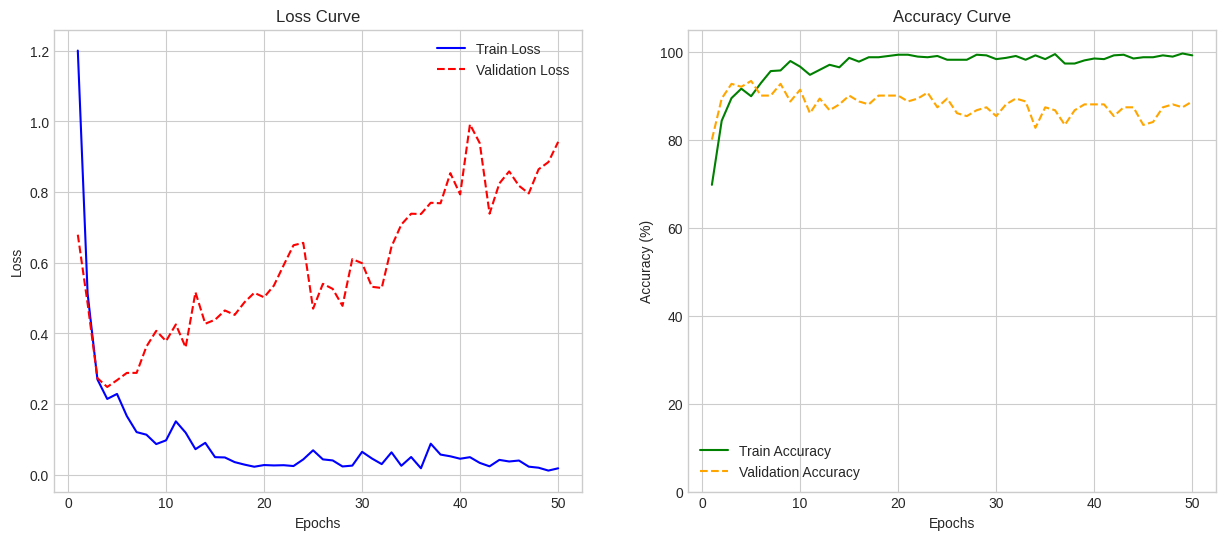

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load Data
excel_path = f'/kaggle/working/custom_{MODEL_TYPE}_training_data.xlsx'
if 'history' not in locals():
    history = pd.read_excel(excel_path)

# 2. Plot
plt.figure(figsize=(15, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Loss
plt.subplot(1, 2, 1)
plt.plot(history['Epoch'], history['Train Loss'], label='Train Loss', color='blue')
plt.plot(history['Epoch'], history['Validation Loss'], label='Validation Loss', color='red', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['Epoch'], history['Train Accuracy'], label='Train Accuracy', color='green')
plt.plot(history['Epoch'], history['Validation Accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.ylim(0, 105) # Scale 0-100%

plt.show()

# Evaluation on Test Set

Loading best model for evaluation...
⚠️ Warning: Best model file not found. Using current model weights.
Evaluating on Test Set...

CLASSIFICATION REPORT
                           precision    recall  f1-score   support

   Bacterial Leaf Disease       0.77      0.89      0.83        38
               Dried Leaf       1.00      1.00      1.00        37
Fungal Brown Spot Disease       1.00      0.95      0.97        38
             Healthy Leaf       0.85      0.76      0.80        37

                 accuracy                           0.90       150
                macro avg       0.91      0.90      0.90       150
             weighted avg       0.91      0.90      0.90       150



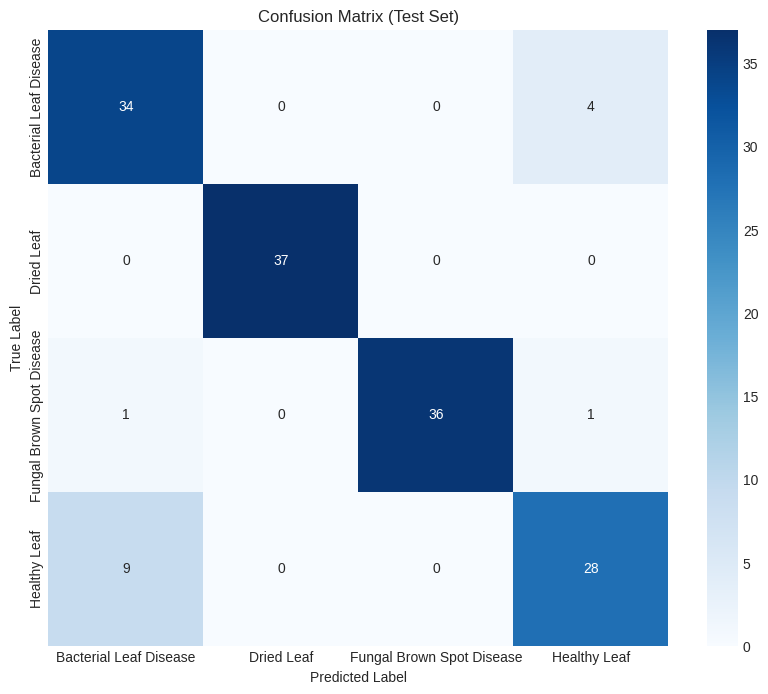

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F
import os

# --- 1. LOAD BEST MODEL ---
print("Loading best model for evaluation...")
if os.path.exists(config.BEST_MODEL_PATH):
    model.load_state_dict(torch.load(config.BEST_MODEL_PATH))
    print(f"✅ Loaded weights from: {config.BEST_MODEL_PATH}")
else:
    print("⚠️ Warning: Best model file not found. Using current model weights.")

model.eval()

# --- 2. GENERATE PREDICTIONS ---
y_true = []
y_pred = []
y_probs = []

print("Evaluating on Test Set...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(config.DEVICE)
        labels = labels.to(config.DEVICE)
        
        # Forward pass
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        # Store results
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

# Convert to numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- 3. CLASSIFICATION REPORT ---
# Get class names
class_names = full_dataset.classes if hasattr(full_dataset, 'classes') else [f"Class {i}" for i in range(config.NUM_CLASSES)]

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))

# --- 4. CONFUSION MATRIX ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# Explainability using Grad-CAM

Generating Grad-CAM Explainability for all 4 classes...


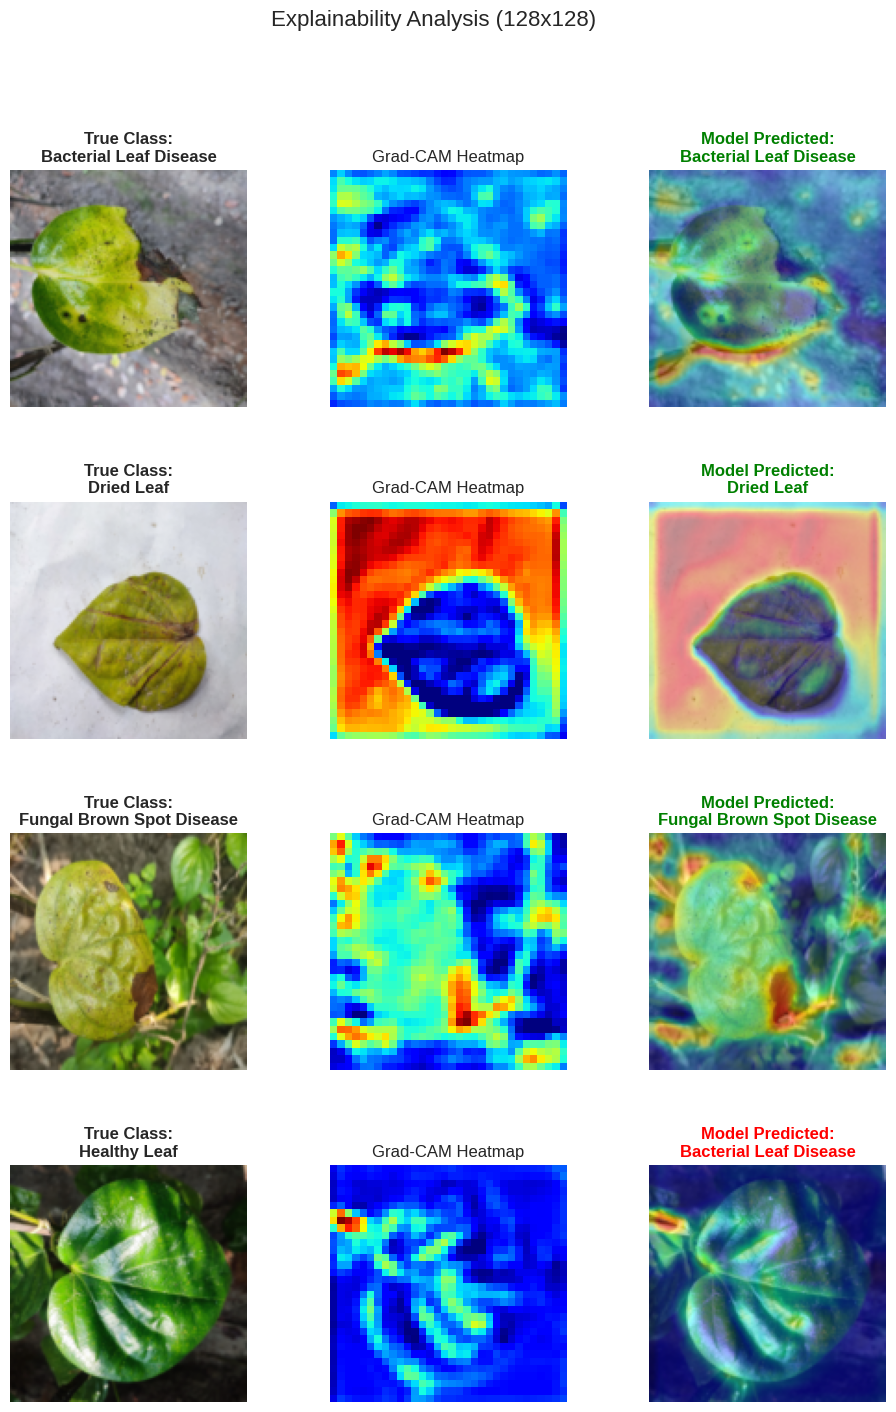

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms

# --- 1. DEFINE GRAD-CAM CLASS ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks to capture gradients and feature maps during forward/backward pass
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        output = self.model(x)
        
        # If class_idx is not provided, use the class with highest probability
        if class_idx is None:
            class_idx = torch.argmax(output)
            
        # Create one-hot encoding for the target class
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        
        # Backward pass to calculate gradients
        output.backward(gradient=one_hot, retain_graph=True)
        
        # 1. Global Average Pooling of Gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # 2. Weight feature maps by the pooled gradients
        activation = self.activations[0].detach()
        for i in range(activation.shape[0]):
            activation[i, :, :] *= pooled_gradients[i]
            
        # 3. Average the channels to create a 2D heatmap
        heatmap = torch.mean(activation, dim=0).cpu().numpy()
        
        # 4. Apply ReLU (we only care about positive influence)
        heatmap = np.maximum(heatmap, 0)
        
        # 5. Normalize heatmap between 0 and 1
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap, class_idx

# --- 2. HELPER: FIND ONE IMAGE PER CLASS ---
def get_images_per_class(dataset, num_classes=4):
    """Finds the index of the first occurrence of each class in the dataset."""
    class_indices = {}
    
    # Shuffle indices to get random examples every time we run
    indices = list(range(len(dataset)))
    import random
    random.shuffle(indices)
    
    for idx in indices:
        _, label = dataset[idx]
        if label not in class_indices:
            class_indices[label] = idx
        
        # Stop once we have found one example for every class
        if len(class_indices) == num_classes:
            break
            
    return class_indices

# --- 3. VISUALIZATION LOGIC ---
print("Generating Grad-CAM Explainability for all 4 classes...")

# A. Initialize GradCAM
# We target the last convolutional layer (defined in your CustomCNN class)
try:
    target_layer = model.get_last_conv_layer()
except AttributeError:
    # Fallback if get_last_conv_layer isn't defined: assume features[8] based on previous code
    target_layer = model.features[8]

grad_cam = GradCAM(model, target_layer)

# B. Get Examples
class_indices = get_images_per_class(test_data, config.NUM_CLASSES)
class_names = full_dataset.classes if hasattr(full_dataset, 'classes') else ["Bacterial", "Dried", "Fungal", "Healthy"]

# C. Setup Plotting (4 rows x 3 columns)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 16))
plt.subplots_adjust(hspace=0.4, wspace=0.1)

# Inverse normalization to display original image correctly
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

# D. Loop through each class and plot
sorted_labels = sorted(class_indices.keys())

for row_idx, label_idx in enumerate(sorted_labels):
    img_idx = class_indices[label_idx]
    
    # Get Data
    img_tensor, true_label = test_data[img_idx]
    input_tensor = img_tensor.unsqueeze(0).to(config.DEVICE)
    
    # Run Grad-CAM
    heatmap, pred_idx = grad_cam(input_tensor)
    
    # Process Original Image for Display
    img_disp = inv_normalize(img_tensor).permute(1, 2, 0).numpy()
    img_disp = np.clip(img_disp, 0, 1) # Clip to ensure valid RGB range
    
    # Process Heatmap
    heatmap_resized = cv2.resize(heatmap, (config.IMAGE_SIZE, config.IMAGE_SIZE))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Create Superimposed Image
    superimposed = cv2.addWeighted(np.uint8(255 * img_disp), 0.6, heatmap_colored, 0.4, 0)
    
    # --- PLOT COLUMN 1: ORIGINAL ---
    axes[row_idx, 0].imshow(img_disp)
    axes[row_idx, 0].set_title(f"True Class:\n{class_names[label_idx]}", fontweight='bold')
    axes[row_idx, 0].axis('off')
    
    # --- PLOT COLUMN 2: HEATMAP ---
    axes[row_idx, 1].imshow(heatmap, cmap='jet')
    axes[row_idx, 1].set_title("Grad-CAM Heatmap")
    axes[row_idx, 1].axis('off')
    
    # --- PLOT COLUMN 3: OVERLAY ---
    axes[row_idx, 2].imshow(superimposed)
    
    # Color code prediction title: Green if correct, Red if wrong
    pred_color = 'green' if pred_idx == label_idx else 'red'
    axes[row_idx, 2].set_title(f"Model Predicted:\n{class_names[pred_idx]}", color=pred_color, fontweight='bold')
    axes[row_idx, 2].axis('off')

plt.suptitle(f"Explainability Analysis ({config.IMAGE_SIZE}x{config.IMAGE_SIZE})", fontsize=16)
plt.show()